In [1]:

import pandas as pd
from sklearn.model_selection import train_test_split

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns

## Препроцесинг

Відкриваємо датасет

In [3]:
cards = pd.read_csv('../cards/cards.csv')

In [4]:
cards.head()

,class index,filepaths,labels,card type,data set
0,0,train/ace of clubs/001.jpg,ace of clubs,ace,train
1,0,train/ace of clubs/002.jpg,ace of clubs,ace,train
2,0,train/ace of clubs/003.jpg,ace of clubs,ace,train
3,0,train/ace of clubs/004.jpg,ace of clubs,ace,train
4,0,train/ace of clubs/005.jpg,ace of clubs,ace,train


In [5]:
# Додаємо нову колонку з мітками мастей карт
cards['suit'] = cards['labels'].apply(lambda x: x.split(' ')[-1])
cards['suit'].value_counts()

suit
spades      2161
hearts      1975
diamonds    1957
clubs       1937
joker        125
Name: count, dtype: int64

Візуалізуємо кількість кожного типу карт

<Axes: xlabel='card type', ylabel='count'>

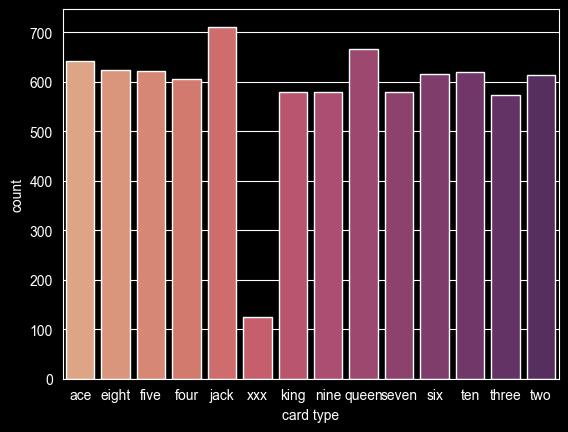

In [6]:
# Seaborn visualization of card types
import seaborn as sns
sns.color_palette("flare")

sns.countplot(x='card type', data=cards, palette='flare', hue='card type')

In [7]:
cards['labels_encoded'] = cards['labels'].astype('category').cat.codes

<Axes: xlabel='labels', ylabel='count'>

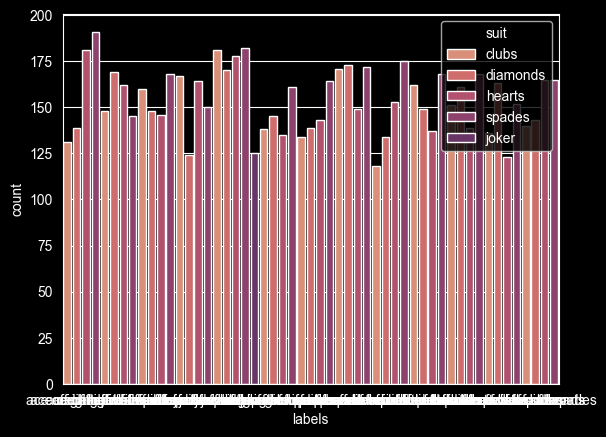

In [8]:
import seaborn as sns
sns.color_palette("flare")
sns.countplot(x='labels', data=cards, palette='flare', hue='suit')

В цілому кожного типу карт приблизно однакова кількість. Це нас не влаштовує. Штучно створюємо дисбаланс класів ділячи їх на карти з обличчями та без. Тут "xxx" - це джокери. Джокери в нас з обличчями. Ace - туз - це карта з цифрою. Цифри на ній немає, але обличчя теж і non-face клас звучить не так красиво як number.

In [9]:
cards['type'] = cards['card type'].apply(lambda x: 'face' if any(face in x for face in ['jack', 'queen', 'king', 'xxx']) else 'number')
cards['type suit'] = cards['type'] + ' ' + cards['suit']

Виводимо по 1 карті з кожного класу та показуємо по 1 представнику кожного з 14 типів з підписом класу карти

In [10]:

df_unique = cards.drop_duplicates(subset=['card type'])
df_unique

,class index,filepaths,labels,card type,data set,suit,labels_encoded,type,type suit
0,0,train/ace of clubs/001.jpg,ace of clubs,ace,train,clubs,0,number,number clubs
602,4,train/eight of clubs/001.jpg,eight of clubs,eight,train,clubs,4,number,number clubs
1186,8,train/five of clubs/001.jpg,five of clubs,five,train,clubs,8,number,number clubs
1768,12,train/four of clubs/001.jpg,four of clubs,four,train,clubs,12,number,number clubs
2333,16,train/jack of clubs/001.jpg,jack of clubs,jack,train,clubs,16,face,face clubs
3004,20,train/joker/001.jpg,joker,xxx,train,joker,20,face,face joker
3119,21,train/king of clubs/001.jpg,king of clubs,king,train,clubs,21,face,face clubs
3658,25,train/nine of clubs/001.jpg,nine of clubs,nine,train,clubs,25,number,number clubs
4198,29,train/queen of clubs/001.jpg,queen of clubs,queen,train,clubs,29,face,face clubs
4823,33,train/seven of clubs/001.jpg,seven of clubs,seven,train,clubs,33,number,number clubs


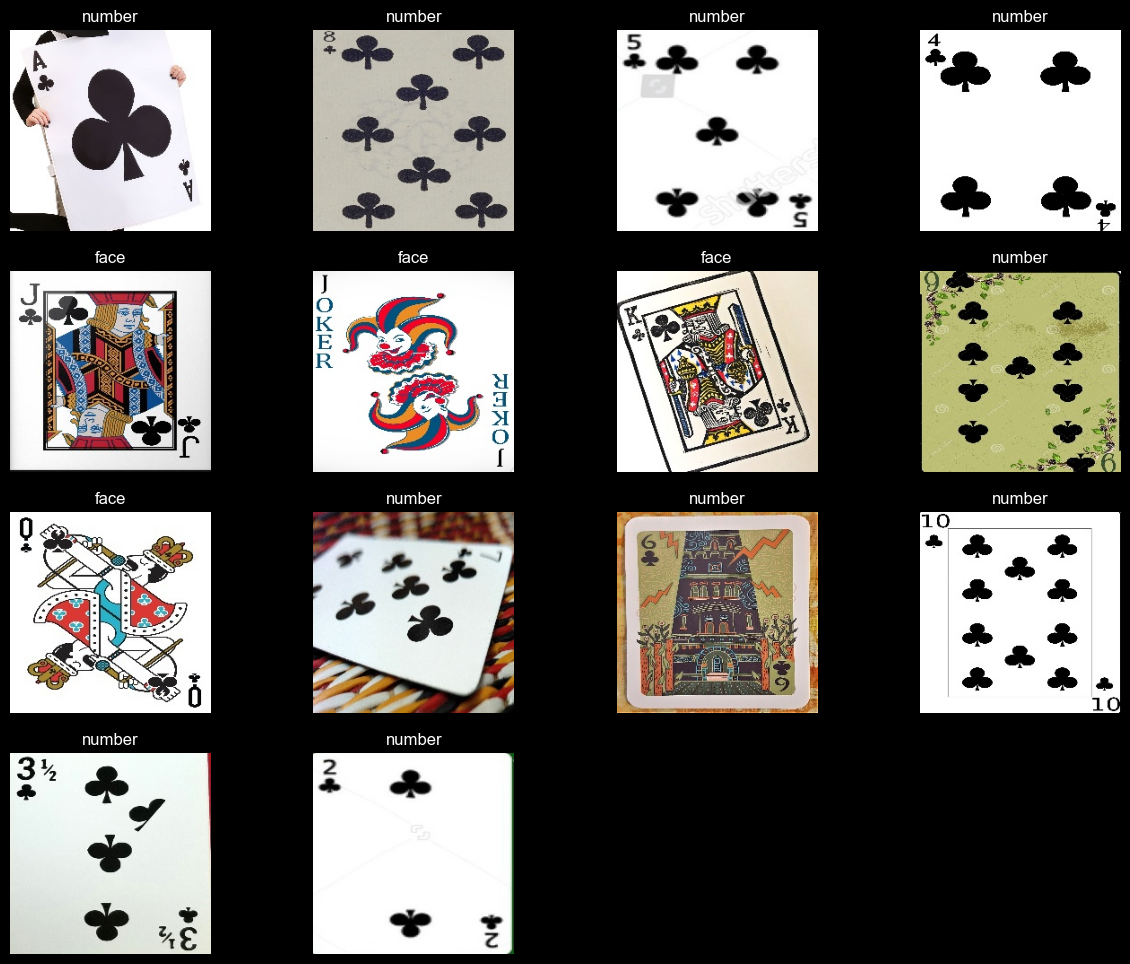

In [11]:
import matplotlib.pyplot as plt
num_cols = 4
num_rows = 4
plt.figure(figsize=(15, num_rows * 3))
for i, card_path in enumerate(df_unique['filepaths']):
    image_path = f'../cards/{card_path}'
    img = plt.imread(image_path)
    plt.subplot(num_rows, num_cols, i+1)
    plt.imshow(img)
    plt.title(df_unique.iloc[i]['type'])
    plt.axis('off')

<Axes: xlabel='type', ylabel='count'>

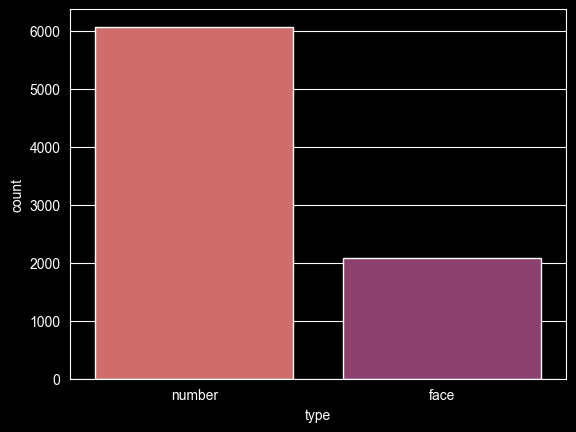

In [12]:
sns.countplot(x='type', data=cards, palette='flare', hue='type')

<Axes: xlabel='type suit', ylabel='count'>

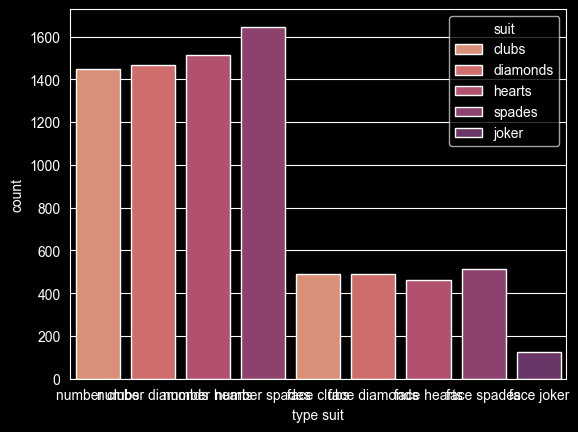

In [13]:
sns.countplot(x='type suit', data=cards, palette='flare', hue='suit')

Тепер датасет більше схожий на незбалансований. Повернемось до карт з обличчями як окремим класам та беремо половину з них.


In [14]:
cards['final_label'] = cards.apply(lambda row: row['type'] if row['type'] == 'number' else row['card type'], axis=1)

In [15]:
for face in ['jack', 'queen', 'king', 'xxx']:
    drop_indices = cards[cards['final_label'] == face].sample(frac=0.5, random_state=42).index
    cards.drop(drop_indices, inplace=True)

<Axes: xlabel='final_label', ylabel='count'>

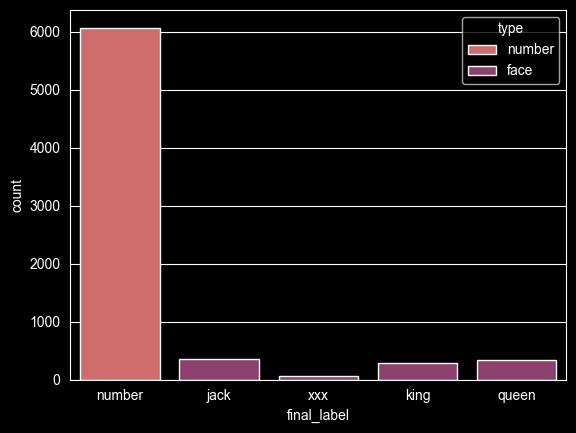

In [16]:
sns.countplot(x='final_label', data=cards, palette='flare', hue='type')

Зберігаємо отриманий датасет у новий CSV файл

In [17]:
cards.to_csv('../cards/processed_cards.csv', index=False)

Датасет готовий. З першої лабораторної з tensorflow_feature_extraction.ipynb отимуємо features - результати передостаннього шару у вигляді вектора з 256 значень.

In [18]:
cards = pd.read_csv('../cards/featured_cards.csv')

In [19]:
cards.head()

,class index,filepaths,labels,card type,data set,suit,labels_encoded,type,type suit,final_label,features,extracted_label,card type encoded
0,0,train/ace of clubs/001.jpg,ace of clubs,ace,train,clubs,0,number,number clubs,number,[0. 0. 0. 0. 0...,0.0,0
1,0,train/ace of clubs/002.jpg,ace of clubs,ace,train,clubs,0,number,number clubs,number,[0. 0. 0. 0. 0...,0.0,0
2,0,train/ace of clubs/003.jpg,ace of clubs,ace,train,clubs,0,number,number clubs,number,[0.0000000e+00 0.0000000e+00 0.0000000e+00 0.0...,0.0,0
3,0,train/ace of clubs/004.jpg,ace of clubs,ace,train,clubs,0,number,number clubs,number,[0. 0. 0. 0. 0...,0.0,0
4,0,train/ace of clubs/005.jpg,ace of clubs,ace,train,clubs,0,number,number clubs,number,[0. 0. 0. 0. 0...,0.0,0


Конвертуємо датасет в набір значень з колонки ознак та цільового маркеру нашого класу

In [20]:
cards['features'] = cards['features'].apply(lambda x: np.fromstring(x[1:-1], sep=' ') if pd.notnull(x) else None)



In [21]:
feature_df = pd.DataFrame.from_records(cards['features'].tolist())
feature_df['final_label'] = cards['final_label'].astype('category').cat.codes
feature_df

,0,1,2,3,4,5,6,7,8,9,...,247,248,249,250,251,252,253,254,255,final_label
0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.000000,0.0,...,0.0,0.000000,0.000000,0.000000,0.0,0.00000,0.0,0.0,0.0,2
1,0.0,0.0,0.0,0.0,0.0,0.020846,0.552028,0.0,0.078372,0.0,...,0.0,0.064447,0.000000,0.033223,0.0,0.00000,0.0,0.0,0.0,2
2,0.0,0.0,0.0,0.0,0.0,0.000000,0.091403,0.0,0.000000,0.0,...,0.0,0.000000,0.000000,0.000000,0.0,0.02428,0.0,0.0,0.0,2
3,0.0,0.0,0.0,0.0,0.0,0.000000,0.021049,0.0,0.000000,0.0,...,0.0,0.000000,0.000000,0.000000,0.0,0.00000,0.0,0.0,0.0,2
4,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.000000,0.0,...,0.0,0.000000,0.000000,0.000000,0.0,0.00000,0.0,0.0,0.0,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7109,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.000000,0.0,...,0.0,0.000000,0.572863,0.000000,0.0,0.00000,0.0,0.0,0.0,2
7110,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.000000,0.0,...,0.0,0.000000,0.531565,0.000000,0.0,0.00000,0.0,0.0,0.0,2
7111,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.000000,0.0,...,0.0,0.000000,0.487464,0.000000,0.0,0.00000,0.0,0.0,0.0,2
7112,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.000000,0.0,...,0.0,0.000000,0.442741,0.000000,0.0,0.00000,0.0,0.0,0.0,2


<Axes: >

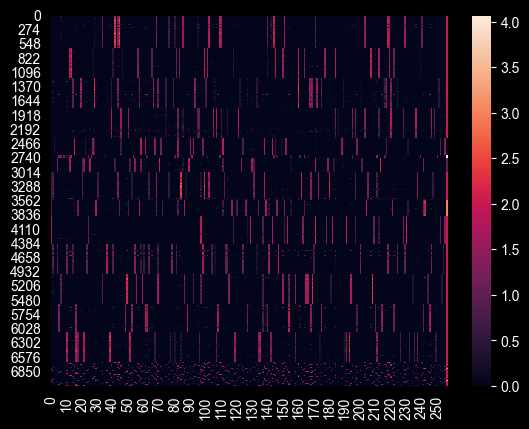

In [22]:
sns.heatmap(feature_df)

## PCA та t-SNE зменшення розмірності

In [23]:
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt



### PCA (2 компоненти)

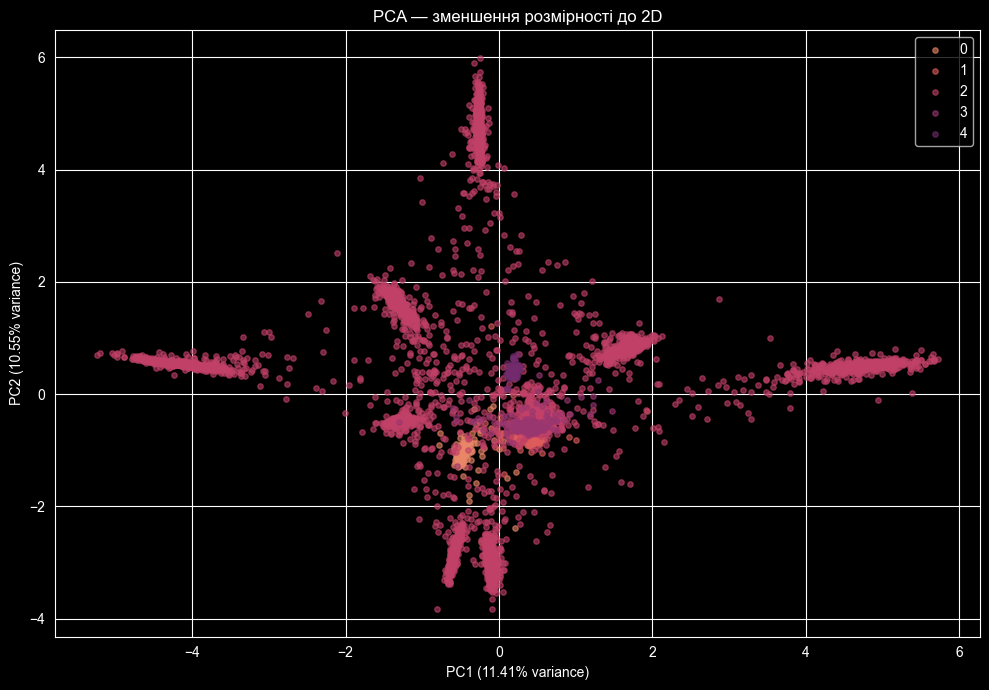

In [24]:
pca = PCA(n_components=2, random_state=42)
x_pca = pca.fit_transform(feature_df.drop(columns=['final_label']).values)

plt.figure(figsize=(10, 7))
unique_labels = np.unique(feature_df['final_label'].values)
palette = sns.color_palette("flare", len(unique_labels))
for i, label in enumerate(unique_labels):
    y = feature_df['final_label'].values == label
    plt.scatter(x_pca[y, 0], x_pca[y, 1], label=label, color=palette[i], alpha=0.6, s=15)
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%} variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%} variance)')
plt.title('PCA — зменшення розмірності до 2D')
plt.legend()
plt.tight_layout()
plt.show()

### t-SNE (2 компоненти)

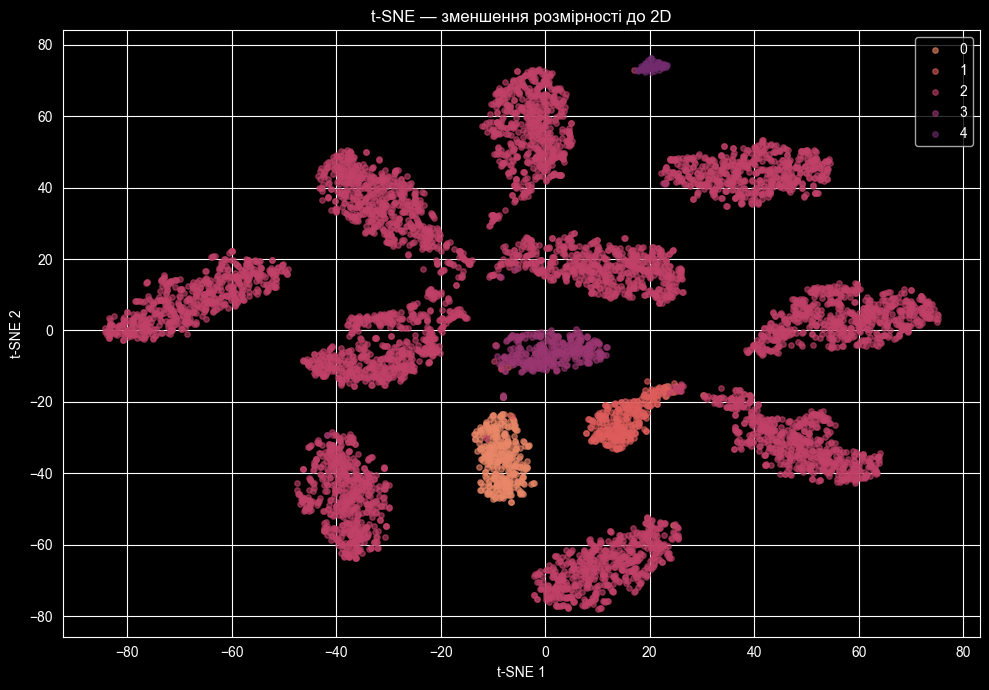

In [25]:
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
x_tsne = tsne.fit_transform(feature_df.drop(columns=['final_label']).values)

plt.figure(figsize=(10, 7))
for i, label in enumerate(unique_labels):
    y = feature_df['final_label'].values == label
    plt.scatter(x_tsne[y, 0], x_tsne[y, 1], label=label, color=palette[i], alpha=0.6, s=15)
plt.xlabel('t-SNE 1')
plt.ylabel('t-SNE 2')
plt.title('t-SNE — зменшення розмірності до 2D')
plt.legend()
plt.tight_layout()
plt.show()

Можна побачити чо на 2d відображенні, окрім домінації найбільшого класу, відноснo добре видно окремі класи. Це пов'язано з тим що для feature extraction використовувалась модель класифікації цього ж датасету, датасет був з малою кількістю даних та класів та з тим що класи є відносно виразними в цьому датасеті. Тепер ігноруємо внутрішній поділ і наново розділимо його на тренувальний та тестовий набори. Тестова вибірка велика через малу кількість даних для демонстрацї результатів наведених в умові методів. Будуємо вказані в завданні класифікатори

In [26]:
from sklearn.model_selection import train_test_split
train_df, test_df = train_test_split(feature_df, test_size=0.5, random_state=42)

## Деяка додаткова інформація про метрики якості

Одне з джерел проблеми незбалансованих даних - складність оцінки результатів роботи нашої
моделі. Через те що в нас існує домінуючий клас який покриває $80-95\%$
наших даних, багато метрик будуть спотворені та показувати значуще
кращий результат ніж насправді.


Нехай наша модель виконала задачу класифікації контрольного набору даних
і передбачила класи подій 1 та 0 (позитивне та негативне передбачення).
В результаті отримуємо *матрицю невідповідності*

True Positive (TP) --- кількість вірних передбачень класу 1,

True Negative (TN) --- ккількість вірних передбачень класу 0,

False Positive (FP) --- кількість невірних передбачень класу 1,

False Negative (FN) --- кількість невірних передбачень класу 0.\
Ця матриця може добре візуалізувати розподіл передбачень класів та буде
корисною в побудові наступних метрик.\

$Accuracy$ показує загальну частку правильно передбачених класів
$$Accuracy = \frac{TP + TN}{TP + TN + FP + FN}$$

Ця метрика не є дуже
підходящою для нашої задачі, оскільки вона завжди буде давати високу
оцінку якості через домінуючий клас. Її використання для оцінки якості
моделі в загальному вигляді має бути обмежено.\

$True Positive Rate$ ($Recall$) характеризує здатність моделі правильно
передбачувати клас 1:

$$Recall = \frac{TP}{TP + FN}.$$

$Precision$
(точність передбачень) визначається як частка правильно передбачених
позитивних серед усіх позитивних прогнозів моделі:

$$Precision = \frac{TP}{TP + FP},$$

$True False Negative$

($Specificity$) визначається як частка правильно передбачених негативних
серед усіх негативних прогнозів моделі:

$$Specificity = \frac{TP}{TP + FP},$$

$F score$ ($F_1-score$) це
узагальнена метрика точності моделі, яка обчислюється на основі
precision та recall і відображає баланс між ними:

$$F score = \frac{2 \cdot precision \cdot recall}{precision + recall},$$

$Precision$ і $Recall$ мають компромісний зв'язок: покращення
$Precision$ часто знижує $Recall$, і навпаки. Оскільки підвищення
$Precision$ зменшить кількість $FP$ результатів для цільового класу, але
при цьому також можливо зменшить $TP$ випадки що зменшить $Recall$.
$F_1-score$ поєднує $Precision$ і $Recall$ в одну метрику, забезпечуючи
більш збалансовану оцінку якості моделі.\
У багатокласовій класифікації F1-score обчислюють двома основними
способами:

-   $Micro\quad averaging$ --- об'єднує результати всіх класів і краще
    підходить для незбалансованих даних.

-   $Macro\quad averaging$ --- обчислює метрику окремо для кожного класу
    та усереднює результати, надаючи всім класам однакову вагу.

## Deep Learning класифікатор (без зваженого тренування)

CNN модель навчена зі стандартною функцією витрат SparseCategoricalCrossentropy. Модель побудована та навчена в tf_classifier.ipynb. Завантажуємо збережену модель та оцінюємо її на тестовому наборі.

In [48]:
import tensorflow as tf
from tensorflow.keras.models import load_model
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, multilabel_confusion_matrix, f1_score
import matplotlib.pyplot as plt

image_height = 128
image_width = 128
batch_size = 32

test_paths = cards.loc[test_df.index, 'filepaths'].apply(lambda x: f'../cards/{x}').values
y = test_df['final_label'].values

def process_input(file_path, y):
    x = tf.io.read_file(file_path)
    x = tf.image.decode_jpeg(x, channels=3)
    x = tf.image.resize(x, [image_height, image_width])
    x = 2 * (tf.cast(x, tf.float32) / 255.0) - 1
    return x, y

test_df_x = tf.data.Dataset.from_tensor_slices((test_paths, y))
test_df_x = test_df_x.map(process_input, num_parallel_calls=tf.data.AUTOTUNE)
test_df_x = test_df_x.batch(batch_size).prefetch(tf.data.AUTOTUNE)

In [49]:
model_default = load_model('default.keras')

y_pred = model_default.predict(test_df_x)
y_pred = tf.argmax(y_pred, axis=1).numpy()

print(f'Accuracy: {accuracy_score(y, y_pred):.4f}')
print()
print(classification_report(y, y_pred))

112/112 ━━━━━━━━━━━━━━━━━━━━ 5s 41ms/step
Accuracy: 0.9131

              precision    recall  f1-score   support

           0       1.00      0.18      0.31       180
           1       0.53      0.62      0.57       138
           2       0.94      1.00      0.97      3047
           3       0.77      0.50      0.61       163
           4       1.00      0.10      0.19        29

    accuracy                           0.91      3557
   macro avg       0.85      0.48      0.53      3557
weighted avg       0.92      0.91      0.90      3557



Побудуємо матрицю невідповідності

Text(33.22222222222222, 0.5, 'Actual')

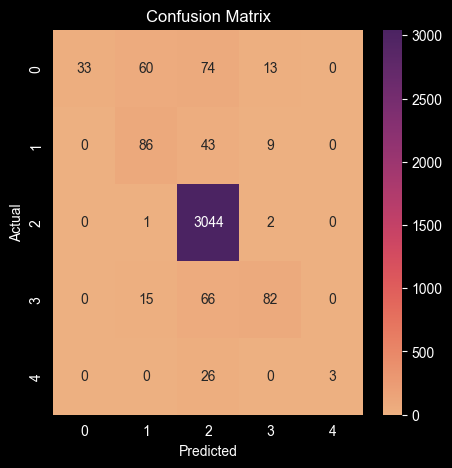

In [50]:
cm = confusion_matrix(y, y_pred)
fig, axes = plt.subplots(1, 1, figsize=(5, 5))
sns.heatmap(cm, annot=True, fmt='d', ax=axes, cmap='flare')
axes.set_title("Confusion Matrix")
axes.set_xlabel('Predicted')
axes.set_ylabel('Actual')

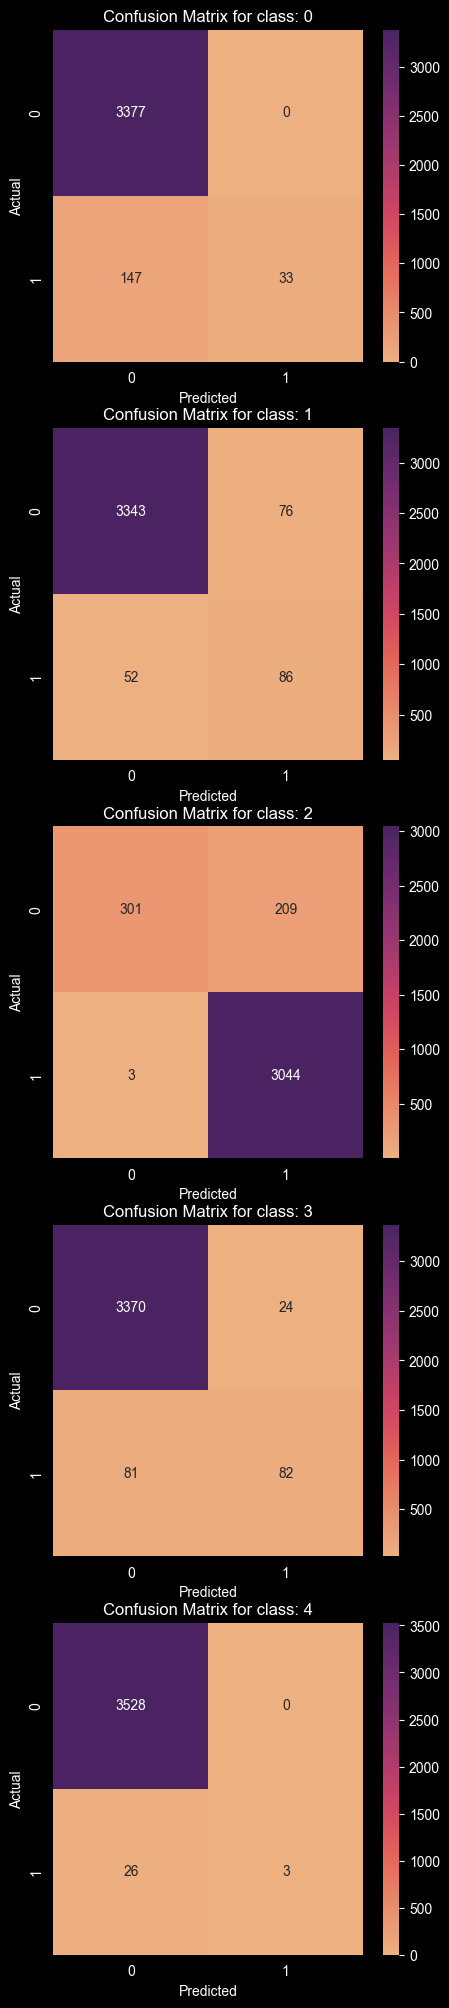

In [51]:
cm = multilabel_confusion_matrix(y, y_pred)
fig, axes = plt.subplots(5, 1, figsize=(5, 25))
for i, m in enumerate(cm):
    sns.heatmap(m, annot=True, fmt='d', ax=axes[i], cmap='flare')
    axes[i].set_title(f"Confusion Matrix for class: {i}")
    axes[i].set_xlabel('Predicted')
    axes[i].set_ylabel('Actual')

In [52]:
acc = []
for m in cm:
	acc.append(float((m[0][0]+m[1][1])/sum(sum(m))))
print('Точність по класам:')
acc

Точність по класам:


[0.9586730390778746,
 0.9640146190610065,
 0.940399212819792,
 0.9704807421984819,
 0.992690469496767]

In [53]:
f1_per_class = f1_score(y, y_pred, average=None)
print('F1 по класам:')
for cls_id, f1 in enumerate(f1_per_class):
    print(f'  Клас {cls_id}: {f1:.4f}')

F1 по класам:
  Клас 0: 0.3099
  Клас 1: 0.5733
  Клас 2: 0.9663
  Клас 3: 0.6097
  Клас 4: 0.1875


Модель без зваженого тренування схильна до "false positive" домінуючого класу, що дає високу загальну точність але низький F1 для малих класів.

## Deep Learning класифікатор (з параметрами ваги)

CNN модель навчена з Focal Loss функцією витрат яка штрафує модель за впевнені але неправильні передбачення домінуючого класу. В tf_classifier.ipynb було обрано alpha = [ 4.00788732,  4.92318339,  0.23424432,  4.27267267, 22.58412698] та gamma = 1.5

In [54]:
model2 = load_model('model_gamma_1.5_type2.keras', compile=False)

y_pred = model2.predict(test_df_x)
y_pred = tf.argmax(y_pred, axis=1).numpy()

print(f'Accuracy: {accuracy_score(y, y_pred):.4f}')
print()
print(classification_report(y, y_pred))

112/112 ━━━━━━━━━━━━━━━━━━━━ 5s 34ms/step
Accuracy: 0.9337

              precision    recall  f1-score   support

           0       0.93      0.44      0.60       180
           1       0.69      0.66      0.67       138
           2       0.97      0.98      0.98      3047
           3       0.62      0.75      0.68       163
           4       0.70      0.97      0.81        29

    accuracy                           0.93      3557
   macro avg       0.78      0.76      0.75      3557
weighted avg       0.94      0.93      0.93      3557



Побудуємо матрицю невідповідності

Text(0.5, 1.0, 'Confusion Matrix')

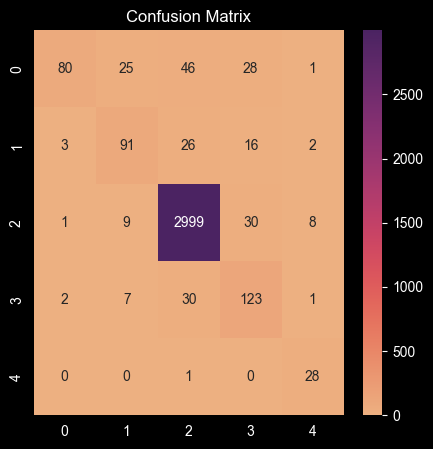

In [55]:
cm = confusion_matrix(y, y_pred)
fig, axes = plt.subplots(1, 1, figsize=(5, 5))
sns.heatmap(cm, annot=True, fmt='d', ax=axes, cmap='flare')
axes.set_title("Confusion Matrix")

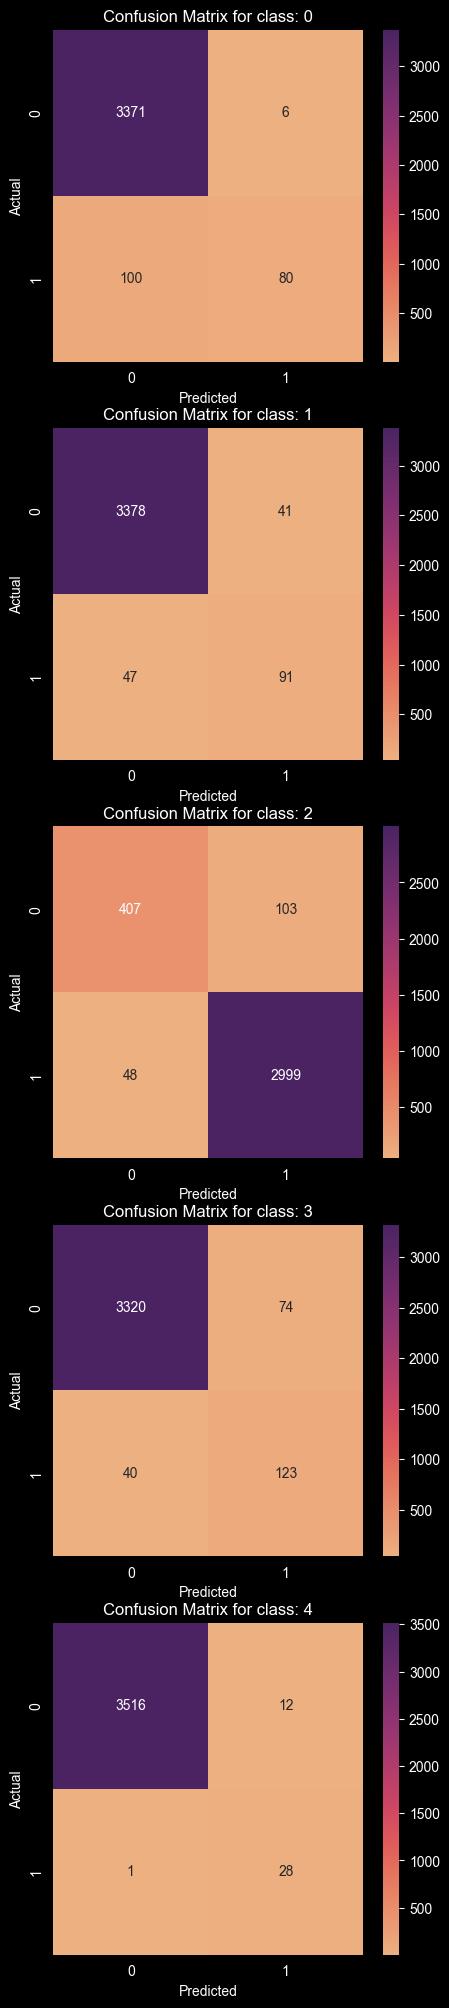

In [56]:
cm = multilabel_confusion_matrix(y, y_pred)
fig, axes = plt.subplots(5, 1, figsize=(5, 25))
for i, m in enumerate(cm):
    sns.heatmap(m, annot=True, fmt='d', ax=axes[i], cmap='flare')
    axes[i].set_title(f"Confusion Matrix for class: {i}")
    axes[i].set_xlabel('Predicted')
    axes[i].set_ylabel('Actual')

In [57]:
acc = []
for m in cm:
	acc.append(float((m[0][0]+m[1][1])/sum(sum(m))))
print('Точність по класам:')
acc

Точність по класам:


[0.970199606409896,
 0.975260050604442,
 0.9575484959235311,
 0.9679505201012089,
 0.9963452347483834]

In [58]:
f1_per_class = f1_score(y, y_pred, average=None)
print('F1 по класам:')
for cls_id, f1 in enumerate(f1_per_class):
    print(f'  Клас {cls_id}: {f1:.4f}')

F1 по класам:
  Клас 0: 0.6015
  Клас 1: 0.6741
  Клас 2: 0.9754
  Клас 3: 0.6833
  Клас 4: 0.8116


Focal Loss допомагає покращити класифікацію не-домінуючих класів за рахунок зменшення впливу легких (домінуючих) прикладів на градієнт. Порівняно з моделлю без ваг, F1 для малих класів зростає.


# Висновок

Дисбаланс даних суттєво впливає на якість deep learning моделей. Стандартна модель без зваженого тренування схильна до вироджених передбачень на користь домінуючого класу. Focal Loss функція витрат зі зваженням класів є дієвим методом для покращення класифікації underrepresented класів в нейронних мережах.

Датасет отримано з https://www.kaggle.com/datasets/gpiosenka/cards-image-datasetclassification/data
